# 第二问：RNN 日前负载与光伏预测实验

用 **2025 年 1 月**训练，在每天 **00:00** 用过去 7 个完整日的十分钟功率预测当天 144 个时段。两个输出分别为负载、光伏功率（kW）。

顺序运行所有单元格。完整包含 `附件2.xlsx`，解压后即可读取；单独下载 Notebook 时，将附件2放在同一目录，或修改下方 `DATA_PATH`。VS Code 右上角选择已有 PyTorch 的 `cumcm2026` 内核。

本版是与 `Q2_GRU_PyTorch.ipynb` 的**受控替换**：只把循环单元从 `nn.GRU` 换成最朴素的 `nn.RNN`，其余输入特征、时间划分、超参数、随机种子、早停规则和评价口径逐字保持不变。这样两者的差距只能归因于循环单元本身，而不是顺带改了别的设置。

对照：昨日同期、上周同期、过去7日均值、RNN、RNN＋日历。两个RNN均使用相同时间特征、结构和训练规则；日历组额外开放星期独热编码、周末标识。日历组不是另一个更大的模型，无日历组对应输入置零。

**先说清预期，避免误读结果。** 朴素 RNN 的隐状态更新是 `h_t = tanh(W_ih x_t + W_hh h_{t-1} + b)`，梯度沿时间反向传播时要连乘 1008 次同一个雅可比矩阵，远端历史的梯度会指数衰减到接近零（梯度消失）；GRU 的更新门/重置门正是为缓解这一点而设计的。因此本版的目的**不是**“换成 RNN 效果更好”，而是把“上一版的效果究竟来自门控单元，还是来自输入特征与残差解码器”变成一个可以检验的对照实验：RNN 明显更差，说明门控确实在起作用；差距很小，说明任务的主要信息量在输入特征一侧，更简单的单元就够用。

**边界：预测是第二问的前端实验，不等于完成购电优化。** 最终仍须将预测及误差接入储能和购电策略，比较实际总费用与应急购电。

In [1]:
from pathlib import Path
import os, random, json, hashlib, platform, time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

DATA_PATH = Path("附件2.xlsx")  # 可改为 Path(r"E:\桌面\CUMCM_2026\附件2.xlsx")
OUT = Path("q2_rnn_results")
LOOKBACK_DAYS = 7
HIDDEN = 32          # 与 GRU 版保持一致，保证同口径对照
BATCH_SIZE = 8
MAX_EPOCHS = 250
PATIENCE = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEEDS = [42, 123, 2026]  # 首次快速调通可改 [42]；正式比较保留3次
SHOW_DAY = "2025-02-01"  # 预先指定，避免按效果挑图
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT.mkdir(exist_ok=True)
print("PyTorch:", torch.__version__, "Device:", DEVICE)
if DEVICE.type == "cuda": print(torch.cuda.get_device_name(0))
assert DATA_PATH.exists(), f"找不到 {DATA_PATH.resolve()}，请修改 DATA_PATH"
assert 1 <= LOOKBACK_DAYS < 24 and MAX_EPOCHS >= 1 and len(SEEDS) > 0

fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    if font in fonts:
        plt.rcParams["font.sans-serif"] = [font]
        break
plt.rcParams["axes.unicode_minus"] = False

PyTorch: 2.12.0 Device: cpu


## 1. 读取原始附件并检查

使用两张工作表，不使用附件3的光伏预报。功率不转成电量。原始列为00:10至24:00，沿用此前报告的“此前十分钟区间平均功率”暂定解释；24:00归属于该行日期，画图用区间末时刻。原题模板时间标签问题应在购电结果提交前单独核实。

禁止用全年均值填补、全年标准化或跨未来插值。本数据应无缺失，异常时停止检查。

In [2]:
load_df = pd.read_excel(DATA_PATH, sheet_name="小区负载", index_col=0)
pv_df = pd.read_excel(DATA_PATH, sheet_name="光伏发电实际功率", index_col=0)
dates = pd.DatetimeIndex(pd.to_datetime(load_df.index))
assert dates.equals(pd.DatetimeIndex(pd.to_datetime(pv_df.index)))
assert load_df.columns.equals(pv_df.columns)
assert dates.equals(pd.date_range("2025-01-01", "2025-12-31"))
assert load_df.shape == pv_df.shape == (365, 144)
y = np.stack([load_df.to_numpy(dtype=np.float32), pv_df.to_numpy(dtype=np.float32)], axis=-1)
assert np.isfinite(y).all(), "存在缺失或非有限数值，先检查原始数据"
assert (y >= 0).all(), "存在负功率，先核实数据"
column_labels = list(map(str, load_df.columns))
print("数据形状（日，时段，目标）:", y.shape)
print("日期范围:", dates.min(), "至", dates.max())
display(load_df.iloc[:3, :6])

数据形状（日，时段，目标）: (365, 144, 2)
日期范围: 2025-01-01 00:00:00 至 2025-12-31 00:00:00


,00:10:00,00:20:00,00:30:00,00:40:00,00:50:00,01:00:00
日期\时间,,,,,,
2025-01-01,3529.7296,3609.5287,3726.56,3510.6311,3502.5625,3787.01
2025-01-02,3622.5509,3622.7611,3708.23,3750.5226,3684.9038,3644.14
2025-01-03,2954.3509,2960.6102,2756.51,2725.0654,2639.7341,2583.76


## 2. 先看一月的周内差异

只使用训练月份绘图。周一至周五和周六日的均值差异仅是描述性结果，不能证明因果。负载可能存在日历规律；光伏更受天气和季节影响，不能预设周末特征对光伏也有效。

`is_weekend` 只表示周六日，不等于法定休息日。此版没有假定地区和调休规则；确认适用日历后再增加节假日及调休特征。月份独热在只有1月训练时学不到其他月份效应，因此默认不加入。

,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,is_weekend
日期\时间,,,,,,,,
2025-01-01,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2025-01-02,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2025-01-03,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2025-01-04,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2025-01-05,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2025-01-06,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-07,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-01-08,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2025-01-09,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


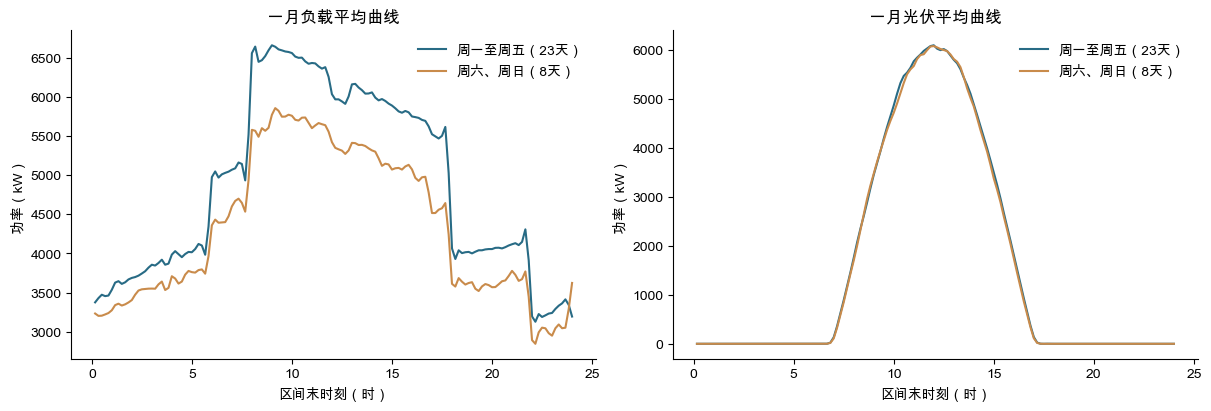

In [3]:
dow = dates.dayofweek.to_numpy()
calendar_features = np.column_stack([np.eye(7)[dow], (dow >= 5).astype(float)]).astype(np.float32)
calendar_names = [f"weekday_{i}" for i in range(7)] + ["is_weekend"]
display(pd.DataFrame(calendar_features[:10], index=dates[:10], columns=calendar_names))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
hours = (np.arange(144) + 1) / 6
for j, ax in enumerate(axes):
    for mask, name, color in [(dow[:31] < 5, "周一至周五", "#286b85"),
                              (dow[:31] >= 5, "周六、周日", "#c98b4b")]:
        ax.plot(hours, y[:31][mask, :, j].mean(axis=0), label=f"{name}（{mask.sum()}天）", color=color)
    ax.set(title=["一月负载平均曲线", "一月光伏平均曲线"][j], xlabel="区间末时刻（时）", ylabel="功率（kW）")
    ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.savefig(OUT / "january_weekday_weekend.png", dpi=220)
plt.show()

## 3. 严格的时间划分与滑动窗口

- 初训：1月1—24日；有7日历史后，训练标签是1月8—24日，共17个日样本。
- 验证：1月25—31日，共7个日样本，只用于早停确定轮数。
- 重训：使用整个1月，按已选轮数从头训练，共24个日样本。
- 主测试：2月；同时导出2—12月逐月结果，观察长期固定模型的漂移。

**第一月有4464个时段，但本实验只有24个可训练的完整日前窗口，不能当成4464个独立样本。**

模型权重在1月末固定；测试时每天更新历史输入，允许看到此前已发生日期的真实功率，不看当天功率。这是逐日滚动预测，不是在1月31日一次预测全年。

RNN 与 GRU 版使用完全相同的输入形状 `(batch, 7×144, 12)`：2个功率、2个时刻周期编码、8个日历输入。无日历组将8维置零。训练窗口内可打乱批次，窗口内时间顺序不打乱，训练验证日期不混合。

In [4]:
train_ids = np.arange(LOOKBACK_DAYS, 24)
val_ids = np.arange(24, 31)
refit_ids = np.arange(LOOKBACK_DAYS, 31)
test_ids = np.arange(31, len(dates))
mu_train = y[:24].mean(axis=(0, 1))
sd_train = np.maximum(y[:24].std(axis=(0, 1)), 1e-6)
mu_full = y[:31].mean(axis=(0, 1))
sd_full = np.maximum(y[:31].std(axis=(0, 1)), 1e-6)
phase = 2 * np.pi * (np.arange(144) + 1) / 144
clock_features = np.column_stack([np.sin(phase), np.cos(phase)]).astype(np.float32)


def make_inputs(values, ids, mean, scale, use_calendar):
    z = (values - mean) / scale
    cal = calendar_features if use_calendar else np.zeros_like(calendar_features)
    xs, auxs, prevs = [], [], []
    for d in ids:
        history = z[d-LOOKBACK_DAYS:d]  # 右端不含预测日
        hist_cal = np.repeat(cal[d-LOOKBACK_DAYS:d], 144, axis=0)
        hist_clock = np.tile(clock_features, (LOOKBACK_DAYS, 1))
        xs.append(np.column_stack([history.reshape(-1, 2), hist_clock, hist_cal]))
        prevs.append(history[-1])
        auxs.append(np.column_stack([history[-1], history.mean(axis=0), clock_features,
                                    np.tile(cal[d], (144, 1))]))
    return tuple(torch.from_numpy(np.asarray(v, dtype=np.float32)) for v in (xs, auxs, prevs))


def make_dataset(ids, mean, scale, use_calendar):
    inputs = make_inputs(y, ids, mean, scale, use_calendar)
    targets = torch.tensor((y[ids] - mean) / scale, dtype=torch.float32)
    return TensorDataset(*inputs, targets)

# 因果检查：任意改掉预测日和未来真值，该日输入必须不变。
changed = y.copy(); changed[31:] = -99999
for cal in [False, True]:
    before = make_inputs(y, [31], mu_full, sd_full, cal)
    after = make_inputs(changed, [31], mu_full, sd_full, cal)
    assert all(torch.equal(a, b) for a, b in zip(before, after))
print("因果输入检查通过；训练/验证/重训/测试日样本:",
      len(train_ids), len(val_ids), len(refit_ids), len(test_ids))

因果输入检查通过；训练/验证/重训/测试日样本: 17 7 24 334


## 4. PyTorch RNN 模型

与 GRU 版**唯一的结构差别**：循环层用 `nn.RNN`（单层、`tanh` 非线性）替换 `nn.GRU`。隐藏维度、输入维度、解码器、损失函数、优化器、批大小、早停规则、随机种子全部不变；由于去掉了门控，参数量比 GRU 版少，这是替换本身带来的，不是刻意缩小模型。

单层 RNN 逐时刻更新 `h_t = tanh(W_ih x_t + W_hh h_{t-1} + b)`，读取过去 1008 个十分钟时段，最终隐藏状态概括历史。共享MLP解码器结合该状态、昨日同期、7日同期均值、预测时刻和已知日历信息，输出全天负载和光伏曲线。输出以昨日曲线为基础预测修正量，因此准确名称为 **RNN历史编码＋共享时段残差解码器**。

这不是递归调用144次的一步预测；当天真实值不会进入解码器。训练损失是两个目标分别标准化后的MSE，避免负载量级压过光伏。使用 `torch.nn.RNN(batch_first=True, nonlinearity='tanh')`，定义参考 [PyTorch RNN文档](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html)。

**本版特别需要注意的两点：**

1. **梯度消失。** 误差要跨 1008 个时刻回传到最早的输入，而 RNN 的隐状态雅可比 `diag(1 - h_t^2) W_hh` 被反复连乘，梯度通常衰减到接近零，模型实际只能利用较近的历史。下面的梯度裁剪只能挡住梯度**爆炸**，挡不住梯度**消失**。
2. **梯度裁剪更关键。** 没有门控时隐状态更新的增益不受限，初始阶段梯度范数明显大于 GRU 版，`clip_grad_norm_(1.0)` 不是可选项。若训练日志出现损失不降或剧烈震荡，先确认这一行仍在。

In [5]:
class DayAheadRNN(nn.Module):
    def __init__(self, hidden=HIDDEN):
        super().__init__()
        # 与 GRU 版唯一的结构差别：循环单元由 nn.GRU 换成最朴素的 nn.RNN（tanh）。
        self.rnn = nn.RNN(input_size=12, hidden_size=hidden, num_layers=1,
                          nonlinearity="tanh", batch_first=True)
        self.decoder = nn.Sequential(nn.Linear(hidden + 14, 32), nn.Tanh(), nn.Linear(32, 2))

    def forward(self, history, future_aux, previous_day):
        _, h = self.rnn(history)
        context = h[-1].unsqueeze(1).expand(-1, 144, -1)
        correction = self.decoder(torch.cat([context, future_aux], dim=-1))
        return previous_day + correction


def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    # 不同显卡/版本间仍可能有细小数值差异，结果文件保留版本和随机种子。


def fit_model(train_ds, validation_ds, seed, fixed_epochs=None):
    set_seed(seed)
    model = DayAheadRNN().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=generator)
    best_loss, best_epoch, stale = float("inf"), 0, 0
    history = []
    for epoch in range(1, (fixed_epochs if fixed_epochs is not None else MAX_EPOCHS) + 1):
        model.train(); total = 0
        for batch in loader:
            x, aux, previous, target = [v.to(DEVICE) for v in batch]
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(x, aux, previous), target)
            if not torch.isfinite(loss): raise RuntimeError("训练损失非有限，请检查输入或学习率")
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            total += loss.item() * len(x)
        val_loss = np.nan
        if validation_ds is not None:
            model.eval()
            with torch.no_grad():
                v = [a.to(DEVICE) for a in validation_ds.tensors]
                val_loss = loss_fn(model(*v[:3]), v[3]).item()
            if not np.isfinite(val_loss): raise RuntimeError("验证损失非有限")
            if val_loss < best_loss - 1e-6:
                best_loss, best_epoch, stale = val_loss, epoch, 0
            else: stale += 1
        history.append({"epoch": epoch, "train_mse": total / len(train_ds), "validation_mse": val_loss})
        if epoch == 1 or epoch % 25 == 0:
            print(f"epoch={epoch:3d} train={total/len(train_ds):.5f} val={val_loss:.5f}")
        if validation_ds is not None and stale >= PATIENCE: break
    # 初训模型不用于测试，仅返回选出的轮数；最终模型从头重训到对应轮数。
    return model, (fixed_epochs if fixed_epochs is not None else best_epoch), pd.DataFrame(history)


@torch.no_grad()
def predict(model, inputs):
    model.eval(); output = []
    loader = DataLoader(TensorDataset(*inputs), batch_size=32, shuffle=False, num_workers=0)
    for batch in loader: output.append(model(*[v.to(DEVICE) for v in batch]).cpu().numpy())
    return np.concatenate(output)

# 运行时检查输出形状、数值及循环层参数梯度确实存在。
set_seed(SEEDS[0])
probe = DayAheadRNN().to(DEVICE)
probe_batch = [v[:2].to(DEVICE) for v in make_dataset(train_ids, mu_train, sd_train, True).tensors]
probe_output = probe(*probe_batch[:3])
assert probe_output.shape == (2, 144, 2) and torch.isfinite(probe_output).all()
((probe_output - probe_batch[3]) ** 2).mean().backward()
assert probe.rnn.weight_ih_l0.grad is not None
assert torch.isfinite(probe.rnn.weight_ih_l0.grad).all()
print("模型形状与梯度检查通过，参数量:", sum(p.numel() for p in probe.parameters()))

# 诊断：同样输入下，比较 RNN 与 GRU 的隐状态回传梯度范数，说明“梯度消失/爆炸”不是空话。
# 只做一次前向+反向，不参与训练，也不影响任何结果。
for cell_cls, cell_kw, cell_name in [(nn.RNN, {"nonlinearity": "tanh"}, "RNN"), (nn.GRU, {}, "GRU")]:
    diagnostic = cell_cls(12, HIDDEN, num_layers=1, batch_first=True, **cell_kw)
    out, _ = diagnostic(probe_batch[0])
    out[:, -1, :].sum().backward()
    print(f"{cell_name} 初始隐层梯度范数: {float(diagnostic.weight_hh_l0.grad.norm()):.3f}")
del probe, probe_batch, probe_output, diagnostic, out

模型形状与梯度检查通过，参数量: 3042
RNN 初始隐层梯度范数: 16.694
GRU 初始隐层梯度范数: 6.476


## 5. 正式运行两个 RNN 实验

每个随机种子：先在1月内选训练轮数，再用整个1月从头训练。两种模型除日历输入是否开放外，结构、初始化规则、超参数和测试日期相同。不会根据2月结果重新选择训练轮数。

初次可用 `SEEDS=[42]` 调通；三种子结果用于判断是否稳定。耗时由显卡决定，训练日志每25轮更新。如果显存不足先减小批大小，调过实验参数后应重新运行全部对照。

无日历组若明显不如“昨日同期”“上周同期”等基线，是朴素 RNN 需要重点报告的失败案例，不要因此只汇报日历组。

In [6]:
predictions = {
    "Yesterday": y[test_ids - 1].copy(),
    "Last_week": y[test_ids - 7].copy(),
    "Mean_7_days": np.stack([y[d-7:d].mean(axis=0) for d in test_ids]),
}
training_records = []
started = time.time()
for use_calendar, label in [(False, "RNN"), (True, "RNN_calendar")]:
    train_ds = make_dataset(train_ids, mu_train, sd_train, use_calendar)
    val_ds = make_dataset(val_ids, mu_train, sd_train, use_calendar)
    refit_ds = make_dataset(refit_ids, mu_full, sd_full, use_calendar)
    test_inputs = make_inputs(y, test_ids, mu_full, sd_full, use_calendar)
    for seed in SEEDS:
        name = f"{label}_{seed}"
        print("\n初训与验证:", name)
        initial_model, best_epoch, log = fit_model(train_ds, val_ds, seed)
        del initial_model
        print("整月重训:", name, "epochs:", best_epoch)
        model, _, refit_log = fit_model(refit_ds, None, seed, fixed_epochs=best_epoch)
        raw = predict(model, test_inputs) * sd_full + mu_full
        # 仅施加物理非负约束；不使用全天真值判夜间，也不设无依据发电上限。
        predictions[name] = np.maximum(raw, 0)
        log.to_csv(OUT / f"{name}_training.csv", index=False)
        refit_log.to_csv(OUT / f"{name}_refit.csv", index=False)
        torch.save({"state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                    "mean": mu_full.tolist(), "scale": sd_full.tolist(), "hidden": HIDDEN,
                    "recurrent_cell": "nn.RNN(tanh)", "lookback_days": LOOKBACK_DAYS,
                    "use_calendar": use_calendar,
                    "seed": seed, "best_epoch": best_epoch, "training_end": "2025-01-31"},
                   OUT / f"{name}.pt")
        training_records.append({"model": name, "seed": seed, "epochs": best_epoch,
                                 "best_validation_mse": log.validation_mse.min()})
        del model
training_summary = pd.DataFrame(training_records)
training_summary.to_csv(OUT / "training_summary.csv", index=False)
print(f"训练和预测完成，用时 {(time.time()-started)/60:.1f} 分钟")
display(training_summary)


初训与验证: RNN_42


epoch=  1 train=0.34697 val=0.32290


epoch= 25 train=0.18977 val=0.20287


epoch= 50 train=0.08892 val=0.12639


epoch= 75 train=0.05750 val=0.09270


...

epoch=175 train=0.01502 val=nan


epoch=200 train=0.01415 val=nan


epoch=225 train=0.01373 val=nan


训练和预测完成，用时 3.7 分钟


,model,seed,epochs,best_validation_mse
0,RNN_42,42,248,0.065719
1,RNN_123,123,248,0.057189
2,RNN_2026,2026,241,0.061476
3,RNN_calendar_42,42,250,0.018330
4,RNN_calendar_123,123,249,0.017559
5,RNN_calendar_2026,2026,249,0.018049


## 6. 评价：主看2月，同时报告逐月与周末表现

分别计算负载、光伏、净负载的MAE、RMSE、偏差。光伏夜间为零，不使用普通MAPE；WAPE采用绝对误差和/真实绝对值和。另报真实光伏大于1kW时段的RMSE（仅评价时筛选，阈值事先固定，训练不使用测试掩码）。

RNN结果展示3个种子的均值和样本标准差，基线只算一次。不要根据测试集挑最佳种子。单日图只帮助理解，结论以整个测试月和分组结果为依据。

In [7]:
test_dates = dates[test_ids]
truth = y[test_ids]
rows = []
periods = {"February": test_dates.month == 2, "Feb_Dec": np.ones(len(test_dates), dtype=bool)}
periods.update({f"month_{m:02d}": test_dates.month == m for m in range(2, 13)})
for model_name, pred in predictions.items():
    for period, pmask in periods.items():
        for daytype, dmask in {"all": np.ones(len(test_dates), dtype=bool),
                               "weekday": test_dates.dayofweek < 5,
                               "weekend": test_dates.dayofweek >= 5}.items():
            mask = pmask & dmask
            for j, target in enumerate(["load", "pv", "net_load"]):
                a = truth[mask, :, j] if j < 2 else truth[mask, :, 0] - truth[mask, :, 1]
                p = pred[mask, :, j] if j < 2 else pred[mask, :, 0] - pred[mask, :, 1]
                error = p - a
                daylight = a > 1
                family = "RNN_calendar" if model_name.startswith("RNN_calendar_") else ("RNN" if model_name.startswith("RNN_") else model_name)
                rows.append({"model": model_name, "family": family, "period": period,
                             "day_type": daytype, "target": target, "days": int(mask.sum()),
                             "MAE_kW": np.abs(error).mean(), "RMSE_kW": np.sqrt(np.mean(error**2)),
                             "bias_kW": error.mean(),
                             "WAPE_pct": 100*np.abs(error).sum()/max(float(np.abs(a).sum()), 1e-9),
                             "pv_active_RMSE_kW": np.sqrt(np.mean(error[daylight]**2)) if j == 1 and daylight.any() else np.nan})
metrics = pd.DataFrame(rows)
metrics.to_csv(OUT / "metrics_all.csv", index=False, encoding="utf-8-sig")
february = metrics.query("period == 'February' and day_type == 'all'")
comparison = february.groupby(["family", "target"])[["MAE_kW", "RMSE_kW"]].agg(["mean", "std"])
comparison.to_csv(OUT / "february_comparison.csv", encoding="utf-8-sig")
display(comparison.round(2))
print("std=NaN 表示只有1次结果（基线或只跑1个种子），不表示误差为0。")
# 同一种子配对看日历特征收益，正值表示误差下降。
paired = []
for seed in SEEDS:
    for target in ["load", "pv", "net_load"]:
        a = february[february.model == f"RNN_{seed}"]
        b = february[february.model == f"RNN_calendar_{seed}"]
        base = float(a.loc[a.target == target, "RMSE_kW"].iloc[0])
        new = float(b.loc[b.target == target, "RMSE_kW"].iloc[0])
        paired.append({"seed": seed, "target": target, "calendar_RMSE_reduction_pct": 100*(base-new)/base})
paired = pd.DataFrame(paired)
paired.to_csv(OUT / "calendar_paired_effect.csv", index=False, encoding="utf-8-sig")
display(paired.round(2))

MAE_kW                 RMSE_kW           
                             mean        std         mean        std
family       target                                                 
Last_week    load      146.440002        NaN   184.380005        NaN
             net_load  255.949997        NaN   371.029999        NaN
             pv        159.720001        NaN   313.339996        NaN
Mean_7_days  load      764.789978        NaN   948.409973        NaN
             net_load  730.210022        NaN   958.219971        NaN
             pv        116.570000        NaN   231.339996        NaN
RNN          load      480.170013  36.470001   598.260010  34.060001
             net_load  502.799988  36.400002   647.369995  41.330002
             pv        133.149994   7.050000   252.179993   8.260000
RNN_calendar load      146.970001   2.840000   195.119995   3.390000
             net_load  232.089996   4.670000   319.459991  10.000000
             pv        136.410004   3.070000   255.009995   5.660000
Yesterday    load      638.299988        NaN  1124.099976        NaN
             net_load  695.150024        NaN  1146.770020        NaN
             pv        132.080002        NaN   274.850006        NaN

std=NaN 表示只有1次结果（基线或只跑1个种子），不表示误差为0。


,seed,target,calendar_RMSE_reduction_pct
0,42,load,69.25
1,42,pv,-0.14
2,42,net_load,52.25
3,123,load,66.35
4,123,pv,-0.77
5,123,net_load,48.74
6,2026,load,66.38
7,2026,pv,-2.54
8,2026,net_load,50.76


## 7. 与 GRU 版本的同口径对照（可选）

这一节回答本版真正要回答的问题：**把 `nn.GRU` 换成 `nn.RNN` 之后，误差差多少。** 评价口径与第6节逐字相同，只按随机种子配对比较，聚合方式也一致。

本节需要 GRU 版的结果文件，按下列顺序自动查找第一个存在的：`../gru/q2_gru_results/`（在 `temp/q2/gru` 下重跑 GRU 版时的默认输出）、`../../q2_gru_results/`（在 `temp/` 下运行时的旧输出目录）。都找不到时本节只打印提示并跳过，不影响前面任何计算，也不需要重训 RNN。

注意两点：RNN 与 GRU 必须使用同一份数据、同一测试区间、同一组种子，否则配对无意义；相差日期或行数时本节直接报错而不是硬算。差异百分比为正表示 RNN 更差。若 GRU 结果来自另一台机器或另一版 PyTorch，微小数值差异不可避免，方向性结论仍可用，但严格同口径应以本机重跑为准。

In [8]:
def february_metrics(pred, day_mask=None):
    """与第6节完全相同的口径，只取2月（可选叠加工作日/周末掩码）。"""
    mask = test_dates.month == 2
    if day_mask is not None: mask = mask & day_mask
    a_all, p_all = truth[mask], pred[mask]
    out = {}
    for j, target in enumerate(["load", "pv", "net_load"]):
        a = a_all[:, :, j] if j < 2 else a_all[:, :, 0] - a_all[:, :, 1]
        p = p_all[:, :, j] if j < 2 else p_all[:, :, 0] - p_all[:, :, 1]
        e = p - a
        out[target] = {"MAE_kW": float(np.abs(e).mean()),
                       "RMSE_kW": float(np.sqrt(np.mean(e ** 2))),
                       "WAPE_pct": float(100*np.abs(e).sum()/max(float(np.abs(a).sum()), 1e-9))}
    return out


def family_names(pred, prefix, calendar):
    """按 family 取模型名；先判日历组，避免 'RNN_' 也匹配到 'RNN_calendar_'。"""
    if calendar: return sorted(n for n in pred if n.startswith(f"{prefix}_calendar_"))
    return sorted(n for n in pred if n.startswith(f"{prefix}_") and not n.startswith(f"{prefix}_calendar_"))


GRU_CANDIDATES = [Path("../gru/q2_gru_results/predictions_10min.csv"),
                  Path("../../q2_gru_results/predictions_10min.csv")]
GRU_CSV = next((p for p in GRU_CANDIDATES if p.exists()), None)
if GRU_CSV is None:
    print("未找到 GRU 对照文件，已查找:", [str(p.resolve()) for p in GRU_CANDIDATES], "——跳过本节的 RNN/GRU 对照。")
    print("生成方法：在 ../gru 目录用同一份附件2重跑 Q2_GRU_PyTorch.ipynb，使其写出 q2_gru_results/predictions_10min.csv；")
    print("或把已算好的 q2_gru_results 目录整体复制到 ../gru/ 下，再只重跑本节（不必重训 RNN）。")
else:
    print("GRU 对照文件:", GRU_CSV.resolve())
    # encoding="utf-8-sig"：导出时带 BOM，不指定会把首列读成 U+FEFF 开头的“date”。
    gru_frame = pd.read_csv(GRU_CSV, encoding="utf-8-sig")
    assert len(gru_frame) == len(test_dates) * 144, "GRU 预测行数与当前测试区间不一致，请用同一份附件2重跑 GRU 版"
    assert (gru_frame["date"].astype(str).to_numpy() ==
            np.repeat(test_dates.strftime("%Y-%m-%d"), 144)).all(), "GRU 预测日期与当前测试日期不一致，无法直接对照"
    # 由导出列名还原 {模型名: (日, 时段, 目标)}，与 predictions 结构一致。
    stem_cols = {}
    for col in gru_frame.columns:
        for suffix, j in (("_load_kw", 0), ("_pv_kw", 1)):
            if col.endswith(suffix): stem_cols.setdefault(col[:-len(suffix)], {})[j] = col
    gru_pred = {stem: np.stack([gru_frame[cols[j]].to_numpy(dtype=np.float64).reshape(len(test_dates), 144)
                                for j in (0, 1)], axis=-1)
                for stem, cols in stem_cols.items() if set(cols) == {0, 1}}

    records = []
    for prefix, calendar, source in [("RNN", False, predictions), ("RNN", True, predictions),
                                     ("GRU", False, gru_pred), ("GRU", True, gru_pred)]:
        names = family_names(source, prefix, calendar)
        if not names: continue
        family = prefix + ("_calendar" if calendar else "")
        for target in ["load", "pv", "net_load"]:
            values = np.array([february_metrics(source[n])[target]["RMSE_kW"] for n in names])
            records.append({"family": family, "target": target, "seeds": len(names),
                            "RMSE_mean_kW": values.mean(),
                            "RMSE_std_kW": values.std(ddof=1) if len(values) > 1 else np.nan})
    side_by_side = pd.DataFrame(records)
    side_by_side.to_csv(OUT / "february_rnn_vs_gru.csv", index=False, encoding="utf-8-sig")
    print("2月整月RMSE（同口径，RNN 与 GRU 各3个种子）:")
    display(side_by_side.pivot(index="target", columns="family", values="RMSE_mean_kW").round(1))

    # 按随机种子一一配对，避免把种子差异误读成结构差异。
    paired_rows = []
    for calendar in [False, True]:
        rnn_by_seed = {n.rsplit("_", 1)[-1]: n for n in family_names(predictions, "RNN", calendar)}
        gru_by_seed = {n.rsplit("_", 1)[-1]: n for n in family_names(gru_pred, "GRU", calendar)}
        common = sorted(set(rnn_by_seed) & set(gru_by_seed), key=int)
        if not common: continue
        for seed in common:
            for target in ["load", "pv", "net_load"]:
                rv = february_metrics(predictions[rnn_by_seed[seed]])[target]["RMSE_kW"]
                gv = february_metrics(gru_pred[gru_by_seed[seed]])[target]["RMSE_kW"]
                paired_rows.append({"family": "RNN_calendar" if calendar else "RNN", "seed": seed, "target": target,
                                    "RNN_RMSE_kW": rv, "GRU_RMSE_kW": gv,
                                    "RNN_minus_GRU_pct": 100*(rv-gv)/gv})
    paired_rnn_gru = pd.DataFrame(paired_rows)
    paired_rnn_gru.to_csv(OUT / "rnn_vs_gru_paired.csv", index=False, encoding="utf-8-sig")
    display(paired_rnn_gru.round(2))
    summary = paired_rnn_gru.groupby(["family", "target"])["RNN_minus_GRU_pct"].agg(["mean", "min", "max"])
    display(summary.round(2))
    print("RNN_minus_GRU_pct > 0 表示 RNN 的 RMSE 更大（更差）；配对为同一种子的 RNN 与 GRU。")
    print("三个种子不是三个独立数据集，这里只用于判断方向是否稳定，不作统计显著性声明。")

GRU 对照文件: /Users/jinyu/workspace/MCM/CUMCM_2026/temp/q2/gru/q2_gru_results/predictions_10min.csv
2月整月RMSE（同口径，RNN 与 GRU 各3个种子）:


family,GRU,GRU_calendar,RNN,RNN_calendar
target,,,,
load,551.1,195.9,598.3,195.1
net_load,597.2,322.6,647.4,319.5
pv,256.6,260.4,252.2,255.0


,family,seed,target,RNN_RMSE_kW,GRU_RMSE_kW,RNN_minus_GRU_pct
0,RNN,42,load,635.75,527.25,20.58
1,RNN,42,pv,261.14,261.82,-0.26
2,RNN,42,net_load,693.15,589.29,17.62
3,RNN,123,load,569.23,600.52,-5.21
4,RNN,123,pv,250.51,258.43,-3.06
5,RNN,123,net_load,612.79,646.98,-5.28
6,RNN,2026,load,589.78,525.49,12.23
7,RNN,2026,pv,244.88,249.58,-1.88
8,RNN,2026,net_load,636.18,555.26,14.57
9,RNN_calendar,42,load,195.51,194.29,0.63


mean   min    max
family       target                     
RNN          load      9.20 -5.21  20.58
             net_load  8.97 -5.28  17.62
             pv       -1.74 -3.06  -0.26
RNN_calendar load     -0.37 -2.03   0.63
             net_load -0.99 -1.34  -0.46
             pv       -2.05 -2.99  -0.37

RNN_minus_GRU_pct > 0 表示 RNN 的 RMSE 更大（更差）；配对为同一种子的 RNN 与 GRU。
三个种子不是三个独立数据集，这里只用于判断方向是否稳定，不作统计显著性声明。


## 8. 指定一天：真实曲线与预测曲线

默认2月1日，使用 `SEEDS[0]`，不挑表现最好种子。先比较两个模型是否抓住负载峰谷和光伏峰值，再看数值误差。改变 `SHOW_DAY` 后只需重跑本节，不必重训。允许的日期为2025-02-01至2025-12-31。

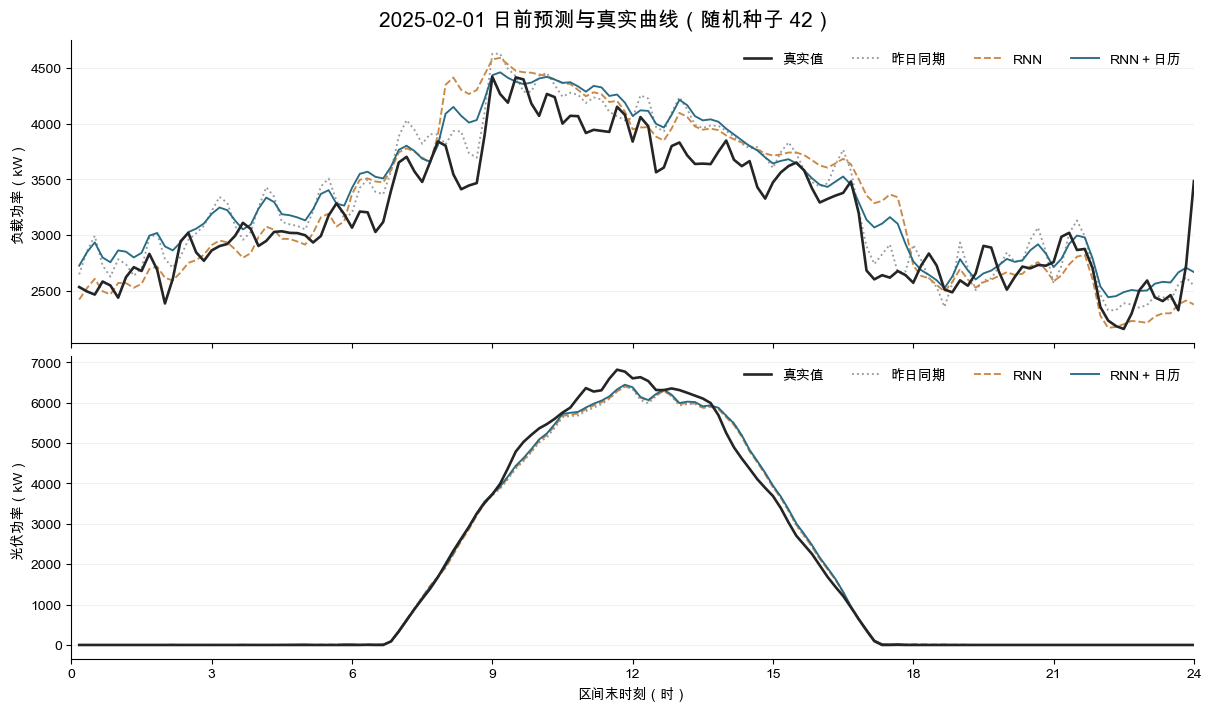

,model,target,MAE_kW,RMSE_kW
0,昨日同期,负载,209.979996,252.169998
1,RNN,负载,218.559998,297.239990
2,RNN＋日历,负载,228.059998,275.760010
3,昨日同期,光伏,101.199997,195.149994
4,RNN,光伏,96.339996,181.619995
5,RNN＋日历,光伏,91.959999,176.880005


In [9]:
def plot_one_day(day=SHOW_DAY, seed=SEEDS[0]):
    found = np.flatnonzero(test_dates == pd.Timestamp(day))
    if len(found) != 1: raise ValueError("请选择2025-02-01至2025-12-31之间的日期")
    i = int(found[0])
    styles = [("Yesterday", "昨日同期", "#969b9f", ":"),
              (f"RNN_{seed}", "RNN", "#cb8845", "--"),
              (f"RNN_calendar_{seed}", "RNN＋日历", "#286b85", "-")]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, layout="constrained")
    day_rows = []
    for j, ax in enumerate(axes):
        ax.plot(hours, truth[i, :, j], color="#252525", lw=1.9, label="真实值", zorder=5)
        for name, label, color, ls in styles:
            ax.plot(hours, predictions[name][i, :, j], color=color, ls=ls, lw=1.35, label=label)
            e = predictions[name][i, :, j] - truth[i, :, j]
            day_rows.append({"model": label, "target": ["负载", "光伏"][j],
                             "MAE_kW": np.abs(e).mean(), "RMSE_kW": np.sqrt(np.mean(e**2))})
        ax.set_ylabel(["负载功率（kW）", "光伏功率（kW）"][j])
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", alpha=.18); ax.legend(ncol=4, frameon=False)
    axes[-1].set(xlabel="区间末时刻（时）", xticks=np.arange(0, 25, 3), xlim=(0, 24))
    fig.suptitle(f"{day} 日前预测与真实曲线（随机种子 {seed}）", fontsize=15)
    fig.savefig(OUT / f"day_{day}_seed{seed}.png", dpi=300)
    fig.savefig(OUT / f"day_{day}_seed{seed}.pdf")
    plt.show()
    table = pd.DataFrame(day_rows)
    table.to_csv(OUT / f"day_{day}_metrics.csv", index=False, encoding="utf-8-sig")
    display(table.round(2))

plot_one_day()
# 看另一日：plot_one_day("2025-02-10")

## 9. 导出预测、来源记录和训练曲线

`predictions_10min.csv` 每行一个时段，含真值及各模型预测；接入调度时功率除以6得到十分钟电量，净负载为负载减光伏，不事先把负净负载清零。此处不覆盖原有 `result2.xlsx`，也不覆盖 GRU 版的 `q2_gru_results`。

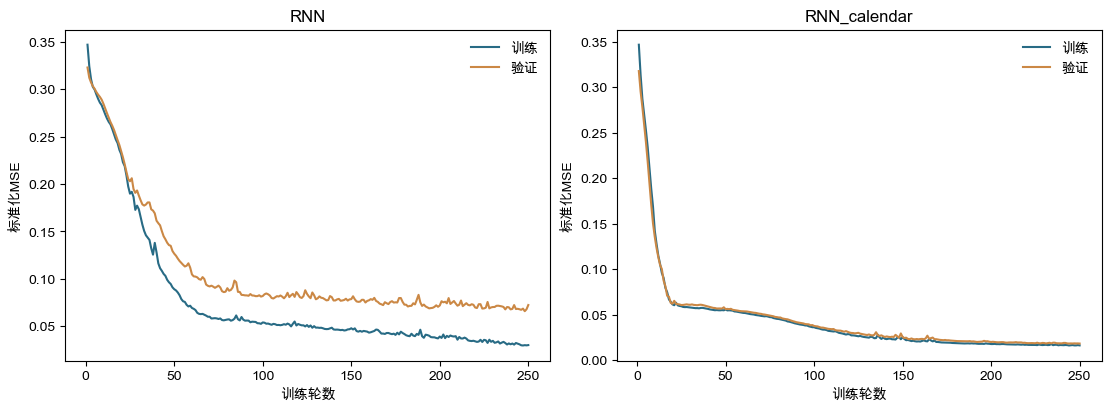

结果目录: /Users/jinyu/workspace/MCM/CUMCM_2026/temp/q2/rnn/q2_rnn_results


In [10]:
export = {"date": np.repeat(test_dates.strftime("%Y-%m-%d"), 144),
          "interval_end": np.tile(column_labels, len(test_dates)),
          "load_actual_kw": truth[:, :, 0].ravel(), "pv_actual_kw": truth[:, :, 1].ravel()}
for name, pred in predictions.items():
    export[name + "_load_kw"] = pred[:, :, 0].ravel()
    export[name + "_pv_kw"] = pred[:, :, 1].ravel()
pd.DataFrame(export).to_csv(OUT / "predictions_10min.csv", index=False, encoding="utf-8-sig")
pd.DataFrame({"forecast_day": test_dates.strftime("%Y-%m-%d"),
              "history_start": dates[test_ids-LOOKBACK_DAYS].strftime("%Y-%m-%d"),
              "history_end": dates[test_ids-1].strftime("%Y-%m-%d"),
              "model_training_end": "2025-01-31"}).to_csv(OUT / "forecast_origins.csv", index=False)
config = {"input_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
          "torch": torch.__version__, "numpy": np.__version__, "python": platform.python_version(),
          "device": str(DEVICE), "lookback_days": LOOKBACK_DAYS, "hidden": HIDDEN,
          "recurrent_cell": "nn.RNN(num_layers=1, nonlinearity=tanh)",
          "recurrent_params": int(sum(p.numel() for n, p in DayAheadRNN().named_parameters()
                                      if n.startswith("rnn."))),
          "batch_size": BATCH_SIZE, "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
          "learning_rate": LR, "weight_decay": WEIGHT_DECAY, "grad_clip": 1.0, "seeds": SEEDS,
          "selection_train_end": "2025-01-24", "validation_end": "2025-01-31",
          "final_training_end": "2025-01-31", "show_day": SHOW_DAY,
          "train_windows": len(train_ids), "refit_windows": len(refit_ids),
          "test_days": len(test_ids), "causal_input_check": "PASS",
          "calendar_features": calendar_names,
          "controlled_swap_of": "Q2_GRU_PyTorch.ipynb (only nn.GRU -> nn.RNN changed)",
          "note": "每天更新历史输入，1月末固定权重；不使用未来真实功率、气象或附件3"}
(OUT / "run_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, family in zip(axes, ["RNN", "RNN_calendar"]):
    frame = pd.read_csv(OUT / f"{family}_{SEEDS[0]}_training.csv")
    ax.plot(frame.epoch, frame.train_mse, label="训练", color="#286b85")
    ax.plot(frame.epoch, frame.validation_mse, label="验证", color="#cb8845")
    ax.set(title=family, xlabel="训练轮数", ylabel="标准化MSE"); ax.legend(frameon=False)
fig.savefig(OUT / "training_curves.png", dpi=220)
plt.show()
print("结果目录:", OUT.resolve())

## 10. 怎样解释结果

1. 先看2月整月RMSE：RNN是否超过昨日同期、上周同期和7日均值？没有超过也应保留，这是有信息量的实验结果。
2. 再看配对种子的日历收益，以及周一至周五/周末分组结果。三个种子不是三个独立数据集，不能据此宣称统计显著。
3. 单日曲线用于展示，不代表整月效果。光伏夜间小幅正预测会被计入误差，此版未利用测试真值强制夜间清零。
4. 只有一月数据时，完整日窗口很少；加入日历特征可能过拟合。一月内验证选出来的轮数也可能有较大波动。
5. 固定一月模型的2—12月结果用于检查外推局限；若随后改为滚动重训，应另建实验并在每一天只用当时可见数据。
6. 负载和光伏误差对净负载、应急购电的影响可能不同。预测RMSE下降不保证购电费用下降，最终需要相同储能约束、初始状态和真实执行规则下的费用回测。
7. **本版是 GRU 版的受控替换，结论必须成对陈述。** 单看 RNN 的 RMSE 说明不了问题，只有“同数据、同种子、同口径下 RNN 比 GRU 差多少”才是有效信息。差距小，说明门控没有带来额外收益，可以考虑更简单的单元、把复杂度留给输入特征；差距大，说明门控捕捉了朴素 RNN 抓不到的长程结构，应保留 GRU。
8. 梯度裁剪只防梯度爆炸，不防梯度消失。若 RNN 明显偏弱且训练曲线正常收敛，最可能的原因是 1008 步回传的梯度消失，而不是学习率或轮数没调好；进一步可做截断反向传播、分段编码或缩短回看窗口的实验，但都是另一组实验，不能在本版结果上事后调参。

本实验使用同一个共享 RNN 同时输出两个目标，尚未检验负载、光伏分别建模的版本。保持实验范围清晰，不把这一结果推广为“所有 RNN 都有效/无效”。